In [2]:
# Load libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import os
import json
import sys
import datetime
from datetime import date, datetime, timedelta
from matplotlib.dates import MO, TU, WeekdayLocator, MonthLocator, YearLocator
from datetime import datetime, UTC, date, timezone
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Rectangle
from matplotlib.ticker import PercentFormatter, StrMethodFormatter
import numpy as np

plots_filepath = 'plots/june-25/'

# Append utils to path for logo import
sys.path.append("utils")
from logo import add_logo


# Make the data on each chart today's date
def format_date_with_suffix(date_obj):
    day = date_obj.day
    # Determine the ordinal suffix
    if 10 <= day % 100 <= 20:
        suffix = 'th'
    else:
        suffix = {1: 'st', 2: 'nd', 3: 'rd'}.get(day % 10, 'th')
    return date_obj.strftime(f"%B {day}{suffix}, %Y")

today = datetime.today()
date = format_date_with_suffix(today)

# Color utils
color_palette = {'Hyperliquid':'#09b882','Bold Blue':'#1f1f60', 'Sky Blue':'#6f85ee', 'Solana Purple':'#9945FF','Engage Orange':'#eda024', 'Dark Slate':'#262935', 'Mauve':'#7c1158', 'Yellow':'#ebdc78', 'Green':'#00b7c7', 'Red':'#b30000','Mid Grey':'#54504c','Other Grey':'#a4a2a8', 'Pure Grey': '#808080','Lighter Grey': '#A9A9A9','Lightest Grey': '#D3D3D3','blue 1':'#03045e', 'blue 2':'#0077b6', 'blue 3':'#00b4d8', 'blue 4':'#90e0ef', 'blue 5':'#caf0f8'}
platform_colors = {
        'Felix': color_palette['Sky Blue'],  
        'Hyperliquid': color_palette['Hyperliquid'],  
        'Jupiter': color_palette['Bold Blue'],      
        'dYdX v4': color_palette['Sky Blue'],      
        'ApeX': color_palette['Engage Orange'],         
        'Holdstation': color_palette['Yellow'],  
        'Vertex Protocol': color_palette['Green'], 
        'GMX': color_palette['Red'],          
        'dYdX v3': color_palette['Dark Slate'],      
        'Drift Protocol': color_palette['Mauve'],
        'RabbitX': color_palette['Mid Grey'],           
        'dYdX': color_palette['Dark Slate'],
        'Gains Network': color_palette['Mauve'],
        'KTX Finance': color_palette['Yellow'],
        'RabbitX': color_palette['Pure Grey'],
        'Aevo': color_palette['Lighter Grey'],
        'Other': color_palette['Other Grey'],
        'Hyperliquid Perps': color_palette['Hyperliquid'],
        'Jupiter Perpetual Exchange': color_palette['Bold Blue'],
        'Vertex Perps': color_palette['Green'],
        'Apex Omni': color_palette['Engage Orange'],
        'MYX Finance': color_palette['Yellow'],
        'edgeX': color_palette['Red'],
        'Ostium': color_palette['Mauve'],
        'RabitX': color_palette['Yellow'],
        'Aark Digital': color_palette['Dark Slate'],
        'dYdX (V3+V4)': color_palette['Sky Blue']
    }

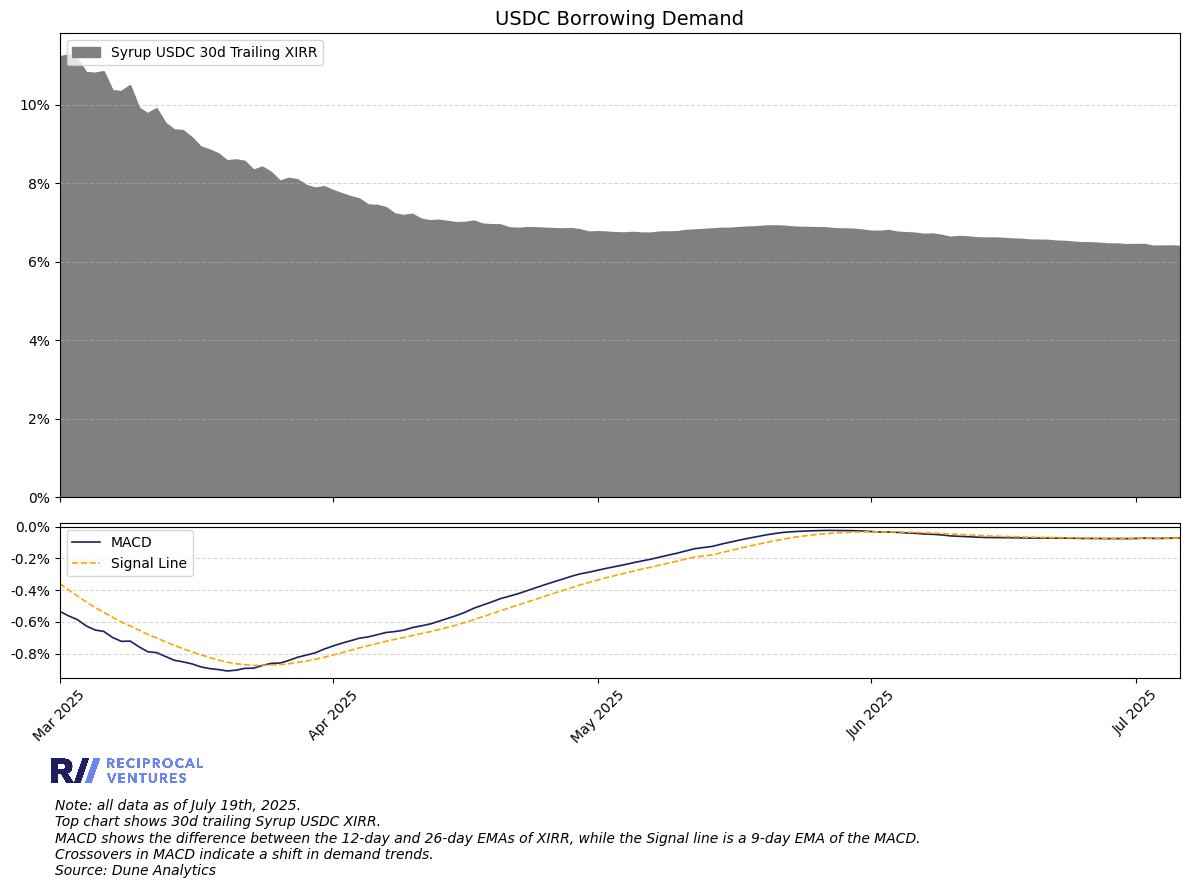

In [3]:
start_date = '2025-03-01'

# Load the JSON file
with open("raw-data/dune-raw-data/dune_maple-xirr.json", "r") as f:
    raw_data = json.load(f)

# Extract relevant rows only for "Syrup USDC"
entries = raw_data["result"]["rows"]
syrup_usdc_rows = [e for e in entries if e["pool_name"] == "Syrup USDC"]

# Convert to DataFrame
df = pd.DataFrame(syrup_usdc_rows)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
df['percent_xirr'] = df['trailing_xirr'] * 100

# Compute EMA and MACD
def compute_ema(values, period):
    ema = [None] * len(values)
    multiplier = 2 / (period + 1)

    # Find first index with enough non-None values
    valid_start = next((i for i in range(len(values)) if values[i] is not None), None)
    if valid_start is None or valid_start + period > len(values):
        return ema  # not enough data

    # Initialize EMA at first valid point
    ema[valid_start + period] = sum(values[valid_start:valid_start + period]) / period

    for i in range(valid_start + period + 1, len(values)):
        if values[i] is not None and ema[i - 1] is not None:
            ema[i] = (values[i] - ema[i - 1]) * multiplier + ema[i - 1]

    return ema

# Extract values
dates = df["date"].tolist()
percent_xirrs = df['percent_xirr'].tolist()

# Calculate EMAs and MACD
ema_12 = compute_ema(percent_xirrs, 12)
ema_26 = compute_ema(percent_xirrs, 26)
macd = [e12 - e26 if e12 is not None and e26 is not None else None for e12, e26 in zip(ema_12, ema_26)]

# Clean None values from MACD before computing signal line
macd_cleaned = [v if v is not None else 0 for v in macd]
signal = compute_ema(macd_cleaned, 9)

# Add back to the dataframe
df['ema_12'] = ema_12
df['ema_26'] = ema_26
df['macd'] = macd_cleaned
df['signal'] = signal

# Filter to cutoff date
df = df[df["date"] >= start_date].reset_index(drop=True)

# Create figure with two subplots (main + MACD)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Area chart for XIRR
ax1.fill_between(df['date'], df['percent_xirr'], color=color_palette['Pure Grey'], alpha=1, label="Syrup USDC 30d Trailing XIRR")
ax1.plot(df['date'], df['percent_xirr'], color=color_palette['Pure Grey'], linewidth=1.5)
ax1.set_title("USDC Borrowing Demand", fontsize=14)
ax1.grid(axis="y", linestyle="--", alpha=0.5)
ax1.legend(loc="upper left")
ax1.set_ylim(bottom=0)

# MACD Indicator
# MACD shows the difference between the 12-day and 26-day EMAs of XIRR, while the Signal line is a 9-day EMA of the MACD. Crossovers may indicate shifts in APY momentum.
ax2.plot(df['date'], df['macd'], label="MACD", color="#1f1f60", linewidth=1.2)
ax2.plot(df['date'], df['signal'], label="Signal Line", color="orange", linestyle="--", linewidth=1.2)
ax2.axhline(0, color="black", linewidth=0.8, linestyle="-")
ax2.grid(axis="y", linestyle="--", alpha=0.5)
ax2.legend(loc="upper left")

# X-axis formatting
ax1.margins(x=0)
ax2.margins(x=0)
ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

# Format y-axis on main chart as %
def percent_formatter_no_decimal(x, pos):
    return f"{x:.0f}%"
def percent_formatter(x, pos):
    return f"{x:.1f}%"
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(percent_formatter_no_decimal))
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(percent_formatter))

# Add Reciprocal logo and source note
add_logo(ax2, position=(0.06, -0.6))
plt.figtext(0.05, -0.1, f"Note: all data as of {date}.\nTop chart shows 30d trailing Syrup USDC XIRR.\nMACD shows the difference between the 12-day and 26-day EMAs of XIRR, while the Signal line is a 9-day EMA of the MACD.\nCrossovers in MACD indicate a shift in demand trends.\nSource: Dune Analytics", ha='left', fontsize=10, style='italic')

# Save and show
imgtitle = "usdc-30d-trailing-xirr-and-macd"
plt.tight_layout()
save_path = os.path.join("plots/june-25/", f"{imgtitle}.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

In [4]:
# Function to plot top protocols by fees or revenue
def top_n_protocols_by_category(metric, category, start_date, end_date, n):
    with open(f'raw-data/defillama-raw-data/{metric}_data/top-protocols-{category}.json', 'r') as f:
        protocols = json.load(f)
    
    asset_colors = ['#1f1f60',
                    '#191F98',
                    '#313EA5',
                    '#4A5DB2',
                    '#637BBF',
                    '#7C9ACC',
                    '#94B9D9',
                    '#ADD8E6',
                    '#333333',
                    '#494949',
                    '#5F5F5F',
                    '#757575',
                    '#8A8A8A',
                    '#A0A0A0',
                    '#B6B6B6',
                    '#CCCCCC'
                   ]
    
    df_master = None
    
    counter = 0
    
    start_date_dt = pd.to_datetime(start_date)
    end_date_dt = pd.to_datetime(end_date) - pd.Timedelta(days=1)
    
    for raw_id, asset in protocols.items():
        with open(f'raw-data/defillama-raw-data/{metric}_data/{raw_id}.json') as f:
            data = json.load(f)
        
        # Select only the two real keys, then rename
        raw_df = pd.DataFrame(
            data['totalDataChart'],
            columns=['date', f'{metric}']
        )
        raw_df.rename(columns={
            'date': 'timestamp',
            f'{metric}': asset
        }, inplace=True)
        raw_df['date'] = pd.to_datetime(raw_df['timestamp'], unit='s')
        raw_df = raw_df[['date', asset]]
        raw_df[asset] = raw_df[asset].rolling(window=7).mean()
    
        # Merge dataframes
        df_master = raw_df if df_master is None else df_master.merge(raw_df, on='date', how='outer')
        df_master.fillna(0).infer_objects(copy=False)
    
        # Iterate coutner by 1
        counter += 1
        
    # Filter by appropriate dates
    df_master = df_master.loc[(df_master['date'] >= start_date_dt) &
    (df_master['date'] < end_date_dt)
    ]
        
    # Sort your master dataframe by date
    df_master = df_master.sort_values('date')

    # Fill NA w/ 0
    df_master = df_master.ffill()
    
    # Grab the last row of numbers
    last_row = df_master.iloc[-1]
    
    # Sort the asset names by descending value on that last row
    asset_list = sorted(
        protocols.values(),
        key=lambda asset: last_row[asset],
        reverse=True
    )

    # Filter asset by desired numbe of protocols
    asset_list = asset_list[:n]

    if n < counter:
        counter = n

    
    # Prepare the values and colors in the right order
    dates   = df_master['date']
    series  = [df_master[asset] for asset in asset_list]
    colors = asset_colors[:len(asset_list)]
    
    # Plot a single stacked‐area call
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.stackplot(
        dates,
        *series,
        labels=asset_list,
        colors=colors
    )
    
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:.1f}m'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.xticks(rotation=45)
    
    ax.legend(loc='upper left', bbox_to_anchor=(0,1), ncol=3)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    add_logo(ax, position=(0.08, -0.17))
    ax.margins(x=0)
    plt.figtext(0.12, -0.11, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: DefiLlama", ha='left', fontsize=10, style='italic')
    if not category.endswith('s'):
        title_category = f'{category}s' # fix formatting so the title category is always plural
    else:
        title_category = category
    if metric == 'dailyFees':
        ax.set_title(f'Top {counter} {title_category} by Daily Fees')
    if metric == 'dailyRevenue':
        ax.set_title(f'Top {counter} {category_category} by Daily Revenue')
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}/{category}-{metric}.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    print(df_master.tail(5))

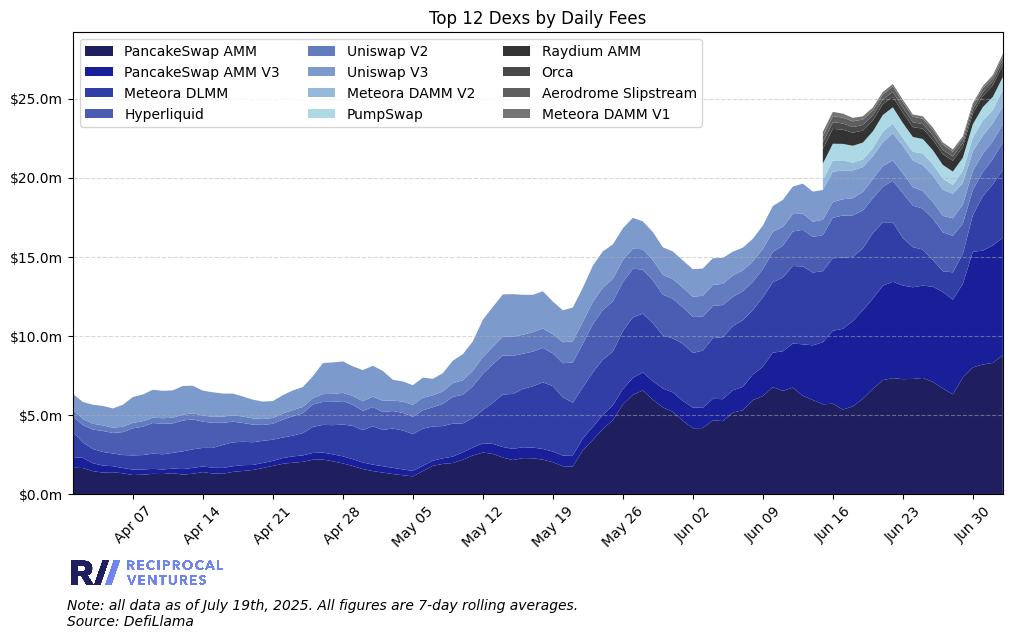

           date  PancakeSwap AMM  PancakeSwap AMM V3  Meteora DLMM  \
1876 2025-06-29     7.362668e+06        5.912124e+06  1.903245e+06   
1877 2025-06-30     8.003850e+06        7.308657e+06  2.325856e+06   
1878 2025-07-01     8.187930e+06        7.196363e+06  3.438983e+06   
1879 2025-07-02     8.290305e+06        7.424210e+06  3.861982e+06   
1880 2025-07-03     8.775110e+06        7.424210e+06  4.298549e+06   

       Hyperliquid    Uniswap V3    Uniswap V2       PumpSwap    Raydium AMM  \
1876  1.911408e+06  1.364998e+06  1.209227e+06  832360.142857  680921.857143   
1877  1.587229e+06  1.230112e+06  1.202111e+06  844014.428571  689104.428571   
1878  1.527925e+06  1.148578e+06  1.150619e+06  855366.285714  695686.142857   
1879  1.600353e+06  1.126997e+06  1.137000e+06  823618.714286  724913.000000   
1880  1.733414e+06  1.126997e+06  1.137000e+06  823618.714286  768879.571429   

      Meteora DAMM V2           Orca  Aerodrome Slipstream  Meteora DAMM V1  \
1876     7.643891e+

In [5]:
# Call the function
metric = 'dailyFees' # 'dailyFees' or 'dailyRevenue'
category = 'Dexs'
start_date = '2025-04-01'
end_date = today
n = 12 # number of protocols to show, max is number pulled down in the raw data

top_n_protocols_by_category(metric, category, start_date, end_date, n)

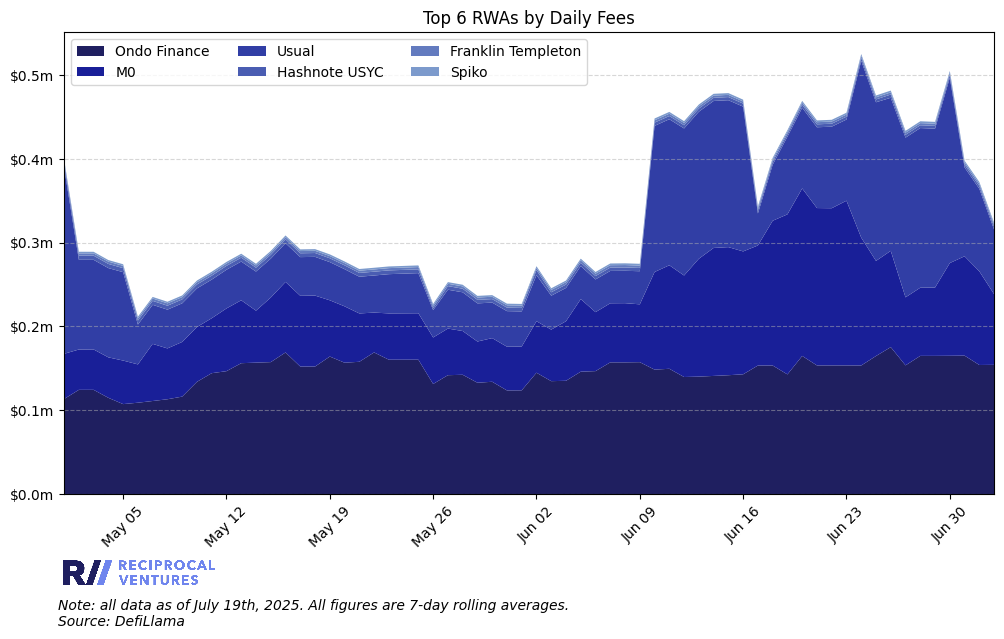

          date   Ondo Finance          Usual             M0  Hashnote USYC  \
788 2025-06-29  164833.428571  189620.428571   81533.000000    3349.285714   
789 2025-06-30  164944.142857  221161.428571  110659.285714    3312.142857   
790 2025-07-01  165123.857143  106006.285714  118579.857143    3302.142857   
791 2025-07-02  153963.857143   98487.285714  111784.285714    3286.714286   
792 2025-07-03  154129.285714   77033.428571   84370.571429    3286.714286   

     Franklin Templeton  Zivoe        Spiko  OpenEden TBILL  Tangible RWA  \
788         2569.714286    0.0  2197.857143     1521.285714           0.0   
789         2573.142857    0.0  2200.857143     1529.571429           0.0   
790         2573.285714    0.0  2198.285714     1538.714286           0.0   
791         2595.428571    0.0  2198.428571     1545.142857           0.0   
792         2595.428571    0.0  2196.428571     1549.571429           0.0   

     Danogo  Superstate USTB  Paxos Gold  
788     0.0              

In [6]:
# Call the function
metric = 'dailyFees' # 'dailyFees' or 'dailyRevenue'
category = 'RWA'
start_date = '2025-05-01'
end_date = today
n = 6 # number of protocols to show, max is number pulled down in the raw data

top_n_protocols_by_category(metric, category, start_date, end_date, n)

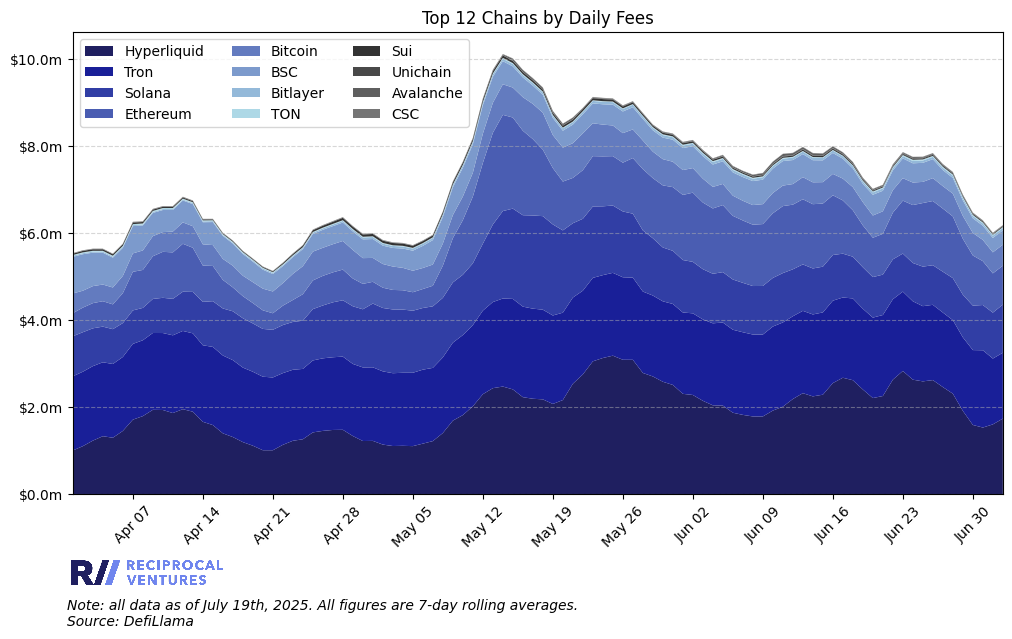

           date   Hyperliquid          Tron      Ethereum        Solana  \
5248 2025-06-29  1.911408e+06  1.690303e+06  1.283988e+06  9.811983e+05   
5249 2025-06-30  1.587229e+06  1.721748e+06  1.152717e+06  1.022221e+06   
5250 2025-07-01  1.527925e+06  1.776529e+06  1.008242e+06  1.040728e+06   
5251 2025-07-02  1.600353e+06  1.513989e+06  9.022194e+05  1.055753e+06   
5252 2025-07-03  1.733414e+06  1.513989e+06  8.944836e+05  1.106876e+06   

            Bitcoin            BSC      Bitlayer     Avalanche           Sui  \
5248  527160.571429  355185.857143  54545.571429  13182.428571  23202.571429   
5249  517738.285714  337325.285714  54575.000000  12125.428571  22511.000000   
5250  488354.000000  326317.714286  54332.428571  10069.428571  22776.428571   
5251  483258.428571  330525.714286  54333.000000   9353.000000  19421.142857   
5252  483258.428571  330525.714286  54333.000000   8194.000000  19421.142857   

               TON      Unichain      Polygon         Near      Card

In [7]:
# Call the function
metric = 'dailyFees' # 'dailyFees' or 'dailyRevenue'
category = 'Chain'
start_date = '2025-04-01'
end_date = today
n = 12 # number of protocols to show, max is number pulled down in the raw data

top_n_protocols_by_category(metric, category, start_date, end_date, n)

In [8]:
# Function compare fees or revenue for a subsect of assets
def compare_assets(metric, category, breakout_assets, start_date, end_date):
    with open(f'raw-data/defillama-raw-data/{metric}_data/top-protocols-{category}.json', 'r') as f:
        protocols = json.load(f)
    
    asset_colors = ['#1f1f60',
                    '#4A5DB2',
                    '#494949',
                    '#A0A0A0'
                   ]
    
    df_master = None

    compare_dict = {}

    start_date_dt = pd.to_datetime(start_date)
    end_date_dt = pd.to_datetime(end_date) - pd.Timedelta(days=1)
    
    for raw_id, asset in protocols.items():
        if asset in breakout_assets:
            compare_dict[raw_id] = asset
            with open(f'raw-data/defillama-raw-data/{metric}_data/{raw_id}.json') as f:
                data = json.load(f)
            
            # Select only the two real keys, then rename
            raw_df = pd.DataFrame(
                data['totalDataChart'],
                columns=['date', f'{metric}']
            )
            raw_df.rename(columns={
                'date': 'timestamp',
                f'{metric}': asset
            }, inplace=True)
            raw_df['date'] = pd.to_datetime(raw_df['timestamp'], unit='s')
            raw_df = raw_df[['date', asset]]
        
            # Merge dataframes
            df_master = raw_df if df_master is None else df_master.merge(raw_df, on='date', how='outer')
            df_master.fillna(0).infer_objects(copy=False)

    # Filter by appropriate dates
    df_master = df_master.loc[(df_master['date'] >= start_date_dt) &
    (df_master['date'] < end_date_dt)
    ]
    
    # Sort your master dataframe by date
    df_master = df_master.sort_values('date')
    print(df_master.tail(5))
    
    # Grab the last row of numbers
    last_row = df_master.iloc[-1]
    
    # Sort the asset names by descending value on that last row
    asset_list = sorted(
        compare_dict.values(),
        key=lambda asset: last_row[asset],
        reverse=True
    )
    
    # Prepare the values and colors in the right order
    dates   = df_master['date']
    series  = [df_master[asset] for asset in asset_list]
    colors = asset_colors[:len(asset_list)]
    
    # Plot a single stacked‐area call
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.stackplot(
        dates,
        *series,
        labels=asset_list,
        colors=colors
    )
    
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000000:.0f}m'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.xticks(rotation=45)
    
    ax.legend(loc='upper left', bbox_to_anchor=(0,1), ncol=3)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    add_logo(ax, position=(0.08, -0.17))
    ax.margins(x=0)
    plt.figtext(0.12, -0.11, f"Note: all data as of {date}. \nSource: DefiLlama", ha='left', fontsize=10, style='italic')
    if metric == 'dailyFees':
        ax.set_title(f'{category}: Daily Fees Comparison')
    if metric == 'dailyRevenue':
        ax.set_title(f'{category}: Daily Revenue Comparison')
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}/breakout-{category}-{metric}-stacked.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    print(df_master.tail(5))

          date  PumpSwap  Raydium AMM      Orca
986 2025-06-29  674382.0       524384  205882.0
987 2025-06-30  940960.0       794458  376364.0
988 2025-07-01  906933.0       648298  263908.0
989 2025-07-02  891593.0      1024762  307677.0
990 2025-07-03       NaN      1019371  355345.0


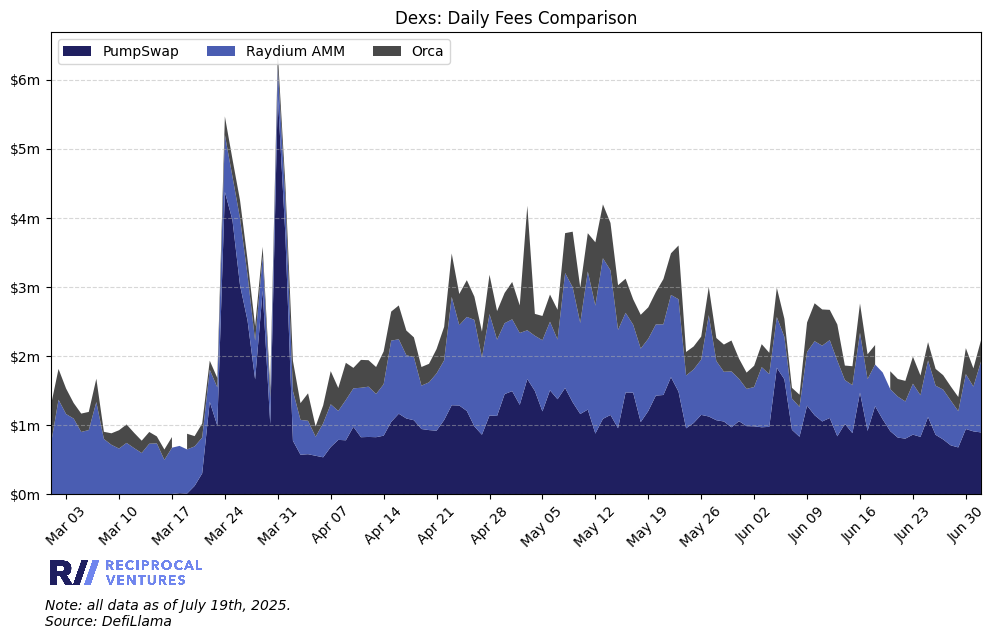

          date  PumpSwap  Raydium AMM      Orca
986 2025-06-29  674382.0       524384  205882.0
987 2025-06-30  940960.0       794458  376364.0
988 2025-07-01  906933.0       648298  263908.0
989 2025-07-02  891593.0      1024762  307677.0
990 2025-07-03       NaN      1019371  355345.0


In [9]:
# Call the function
category = 'Dexs'
start_date = '2025-03-01'
end_date = today
breakout_assets = ['Hyperliquid Spot Orderbook', 'PumpSwap', 'Raydium AMM', 'Orca']

compare_assets(metric, category, breakout_assets, start_date, end_date)

In [10]:
# Function compare fees or revenue for a subsect of assets
def compare_assets(metric, category, breakout_assets, start_date, end_date):
    with open(f'raw-data/defillama-raw-data/{metric}_data/top-protocols-{category}.json', 'r') as f:
        protocols = json.load(f)
    
    asset_colors = ['#1f1f60',
                    '#4A5DB2',
                    '#494949',
                    '#A0A0A0'
                   ]
    
    df_master = None

    compare_dict = {}

    start_date_dt = pd.to_datetime(start_date)
    end_date_dt = pd.to_datetime(end_date) - pd.Timedelta(days=1)
    
    for raw_id, asset in protocols.items():
        if asset in breakout_assets:
            compare_dict[raw_id] = asset
            with open(f'raw-data/defillama-raw-data/{metric}_data/{raw_id}.json') as f:
                data = json.load(f)
            
            # Select only the two real keys, then rename
            raw_df = pd.DataFrame(
                data['totalDataChart'],
                columns=['date', f'{metric}']
            )
            raw_df.rename(columns={
                'date': 'timestamp',
                f'{metric}': asset
            }, inplace=True)
            raw_df['date'] = pd.to_datetime(raw_df['timestamp'], unit='s')
            raw_df = raw_df[['date', asset]]
            raw_df[asset] = raw_df[asset].rolling(window=7).mean()
        
            # Merge dataframes
            df_master = raw_df if df_master is None else df_master.merge(raw_df, on='date', how='outer')
            df_master.fillna(0).infer_objects(copy=False)

    # Filter by appropriate dates
    df_master = df_master.loc[(df_master['date'] >= start_date_dt) &
    (df_master['date'] < end_date_dt)
    ]
    
    # Sort your master dataframe by date
    df_master = df_master.sort_values('date')
    print(df_master.tail(5))
    
    # Grab the last row of numbers
    last_row = df_master.iloc[-1]
    
    # Sort the asset names by descending value on that last row
    asset_list = sorted(
        compare_dict.values(),
        key=lambda asset: last_row[asset],
        reverse=True
    )
    
    # Plot a single stacked‐area call
    fig, ax = plt.subplots(figsize=(12, 6))
    for i, asset in enumerate(asset_list):
        ax.plot(
            df_master['date'],
            df_master[asset],
            color = asset_colors[i],
            linewidth = 2,
            label=asset
        )
    
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000000:.0f}m'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.xticks(rotation=45)
    
    ax.legend(loc='upper left', bbox_to_anchor=(0,1), ncol=2)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    add_logo(ax, position=(0.08, -0.17))
    ax.margins(x=0)
    plt.figtext(0.12, -0.11, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: DefiLlama", ha='left', fontsize=10, style='italic')
    if metric == 'dailyFees':
        ax.set_title(f'{category}: Daily Fees Comparison')
    if metric == 'dailyRevenue':
        ax.set_title(f'{category}: Daily Revenue Comparison')
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}/breakout-{category}-{metric}-line.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    print(df_master.tail(5))

          date       PumpSwap    Raydium AMM           Orca
986 2025-06-29  832360.142857  680921.857143  257765.428571
987 2025-06-30  844014.428571  689104.428571  255599.000000
988 2025-07-01  855366.285714  695686.142857  252400.857143
989 2025-07-02  823618.714286  724913.000000  258567.285714
990 2025-07-03            NaN  768879.571429  274662.857143


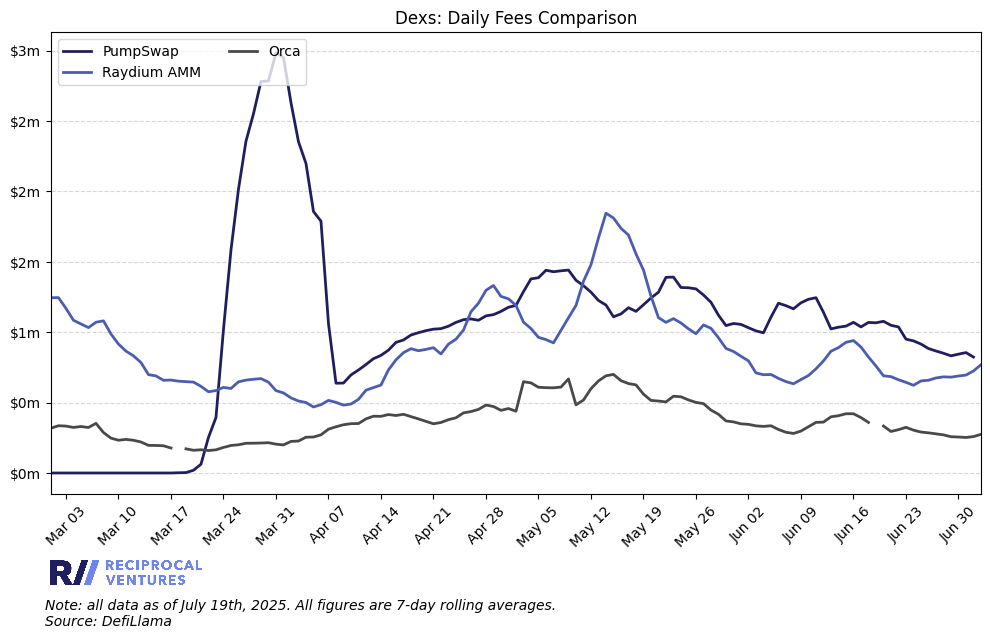

          date       PumpSwap    Raydium AMM           Orca
986 2025-06-29  832360.142857  680921.857143  257765.428571
987 2025-06-30  844014.428571  689104.428571  255599.000000
988 2025-07-01  855366.285714  695686.142857  252400.857143
989 2025-07-02  823618.714286  724913.000000  258567.285714
990 2025-07-03            NaN  768879.571429  274662.857143


In [11]:
# Call the function
category = 'Dexs'
start_date = '2025-03-01'
end_date = today
breakout_assets = ['Hyperliquid Spot Orderbook', 'PumpSwap', 'Raydium AMM', 'Orca']

compare_assets(metric, category, breakout_assets, start_date, end_date)

In [12]:
# Function for plotting revenue or fees / mcap or fdv charts for a set of assets

def revenue_vs_fdv_asset(start_date, assets, breakout_asset, bottom_metric, top_metric, category_title):
    df_master = None
    # Load revenue and FDV data
    for asset_slug, asset_name in assets.items():
        rev_path = f"raw-data/defillama-raw-data/daily{bottom_metric}_data/{asset_slug}_{bottom_metric}.json"
        with open(rev_path) as rev_f:
            rev_data = json.load(rev_f)
    
        rev_df = pd.DataFrame(rev_data["totalDataChart"], columns=["timestamp", f"{asset_slug}-{bottom_metric}"])
        rev_df["date"] = pd.to_datetime(rev_df["timestamp"], unit="s")
        rev_df[f"{asset_slug}-annualized-{bottom_metric}"] = rev_df[f"{asset_slug}-{bottom_metric}"] * 365
        rev_df = rev_df[["date", f"{asset_slug}-annualized-{bottom_metric}"]]

        # Load fdv data
        fdv_path = f'raw-data/messari-raw-data/messari_{asset_slug}_marketcap.json'
        with open(fdv_path) as fdv_f:
            fdv_data = json.load(fdv_f)
        
        points = fdv_data['data']['points']
        fdv_df = pd.DataFrame(points, columns=[
            'timestamp',
            'circulating-marketcap',
            'circulating-marketcap-dominance',
            'fully-diluted-marketcap'
        ])
        fdv_df["date"] = pd.to_datetime(fdv_df["timestamp"], unit="s")
        if top_metric == 'FDV':
            fdv_df = fdv_df[['date','fully-diluted-marketcap']]
            fdv_df.rename(columns={'fully-diluted-marketcap': f'{asset_slug}-{top_metric}'}, inplace=True)

        if top_metric == 'MCAP':
            fdv_df = fdv_df[['date','circulating-marketcap']]
            fdv_df.rename(columns={'circulating-marketcap': f'{asset_slug}-{top_metric}'}, inplace=True)
        
        # Merge datasets for a given asset
        interim_df = pd.merge(rev_df, fdv_df, on="date", how="inner")
        
        # Calculate multiple
        interim_df[f'{asset_slug}-{top_metric}-to-annualized-{bottom_metric}-multiple'] = interim_df[f'{asset_slug}-{top_metric}'] / interim_df[f'{asset_slug}-annualized-{bottom_metric}']
        interim_df[f'{asset_slug}-{top_metric}-to-annualized-{bottom_metric}-multiple-7d'] = interim_df[f'{asset_slug}-{top_metric}-to-annualized-{bottom_metric}-multiple'].rolling(window=7).mean()
        
        # Merge asset dataframe into the master dataframe
        df_master = interim_df if df_master is None else df_master.merge(interim_df, on="date", how="outer")
        df_master = df_master.sort_values("date").reset_index(drop=True)

    # Cut off df_master to only be after start date
    df_master = df_master[df_master['date'] >= start_date]
    
    # define which asset to exclude
    exclude = breakout_asset[0]
    
    # only include the others
    fdv_cols = [
        f"{slug}-{top_metric}"
        for slug in assets
        if slug != exclude
    ]
    mult_cols = [
        f"{slug}-{top_metric}-to-annualized-{bottom_metric}-multiple"
        for slug in assets
        if slug != exclude
    ]
    
    # per-row FDV denominator
    fdv_den = df_master[fdv_cols].sum(axis=1)
    
    # row-wise weights for each FDV column
    weights = df_master[fdv_cols].div(fdv_den, axis=0)
    
    # compute each asset’s weighted term
    weighted_terms = []
    for fdv_col, mult_col in zip(fdv_cols, mult_cols):
        term = weights[fdv_col] * df_master[mult_col]
        weighted_terms.append(term)
    
    # sum them to get your per-day FDV-weighted average
    df_master[f'{top_metric}_weighted_avg_multiple'] = sum(weighted_terms)

    df_master[f'{top_metric}_weighted_avg_multiple-7d'] = df_master[f'{top_metric}_weighted_avg_multiple'].rolling(window=7).mean()
    
    # Create the line chart
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plotting the line chart with custom colors
    for asset_slug, asset_name in assets.items():
        ax.plot(
            df_master['date'], 
            df_master[f'{asset_slug}-{top_metric}-to-annualized-{bottom_metric}-multiple-7d'], 
            label=asset_name, 
            linewidth=2
        )
    
    # Setting labels and title
    ax.set_title(f'{category_title}: {top_metric} / Annualized {bottom_metric}')
    ax.margins(x=0)
    ax.xaxis.set_major_locator(MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}x'))

    # Add grid lines for better readability
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    # Add logo
    add_logo(ax, position=(0.075, -0.18))
    
    # Add sources and note
    text_box = ax.text(0, -0.27, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: DefiLlama and Messari.",
                       ha='left', transform=ax.transAxes, fontsize=10,
                       bbox=dict(facecolor='white', alpha=0), fontstyle='italic')
    
    # Center the legend below the chart
    plt.legend(title=f'Select {category_title}', bbox_to_anchor=(0.85, -0.13), loc='upper center', ncol=2)
    
    # Ensure the layout adapts to fit all elements (legend, text, etc.)
    plt.tight_layout()
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}/{category_title} multiples.png", dpi=300, bbox_inches='tight')
    
    # Show
    plt.show()

    # Calculate statistical percentiles for multiple
    median_cohort = round(df_master[f'{top_metric}_weighted_avg_multiple'].median(), 0)
    percentile_80_cohort = round(df_master[f'{top_metric}_weighted_avg_multiple'].quantile(0.80),0)
    percentile_20_cohort = round(df_master[f'{top_metric}_weighted_avg_multiple'].quantile(0.20),0)
    latest_cohort_multiple = round(df_master[f'{top_metric}_weighted_avg_multiple'].dropna().iloc[-1],0)
    median_breakout = round(df_master[f'{breakout_asset[0]}-{top_metric}-to-annualized-{bottom_metric}-multiple'].median(), 0)
    percentile_80_breakout = round(df_master[f'{breakout_asset[0]}-{top_metric}-to-annualized-{bottom_metric}-multiple'].quantile(0.80),0)
    percentile_20_breakout = round(df_master[f'{breakout_asset[0]}-{top_metric}-to-annualized-{bottom_metric}-multiple'].quantile(0.20),0)
    latest_breakout_multiple = round(df_master[f'{breakout_asset[0]}-{top_metric}-to-annualized-{bottom_metric}-multiple'].dropna().iloc[-1],0)

    stats_cohort = {
        "median_multiple": median_cohort,
        "80th_percentile_multiple": percentile_80_cohort,
        "20th_percentile_multiple": percentile_20_cohort,
        'latest_multiple': latest_cohort_multiple
    }

    stats_breakout = {
        "median_multiple": median_breakout,
        "80th_percentile_multiple": percentile_80_breakout,
        "20th_percentile_multiple": percentile_20_breakout,
        'latest_multiple': latest_breakout_multiple
    }
    
    # Print results in human-readable format
    print()
    print(f"{category_title} {top_metric} / Annualized {bottom_metric} Statistics (Excluding {breakout_asset[1]}):")
    print(f"Median {top_metric} / Annualized {bottom_metric}: {median_cohort:,.0f}x")
    print(f"80th Percentile {top_metric} / Annualized {bottom_metric}: {percentile_80_cohort:,.0f}x")
    print(f"20th Percentile {top_metric} / Annualized {bottom_metric}: {percentile_20_cohort:,.0f}x")
    print(f"Latest Multiple: {latest_cohort_multiple:,.0f}x")
    print()
    print(f"{breakout_asset[1]} {top_metric} / Annualized {bottom_metric} Statistics:")
    print(f"Median {top_metric} / Annualized {bottom_metric}: {median_breakout:,.0f}x")
    print(f"80th Percentile {top_metric} / Annualized {bottom_metric}: {percentile_80_breakout:,.0f}x")
    print(f"20th Percentile {top_metric} / Annualized {bottom_metric}: {percentile_20_breakout:,.0f}x")
    print(f"Latest Multiple: {latest_breakout_multiple:,.0f}x")
    print()

    return stats_cohort, stats_breakout

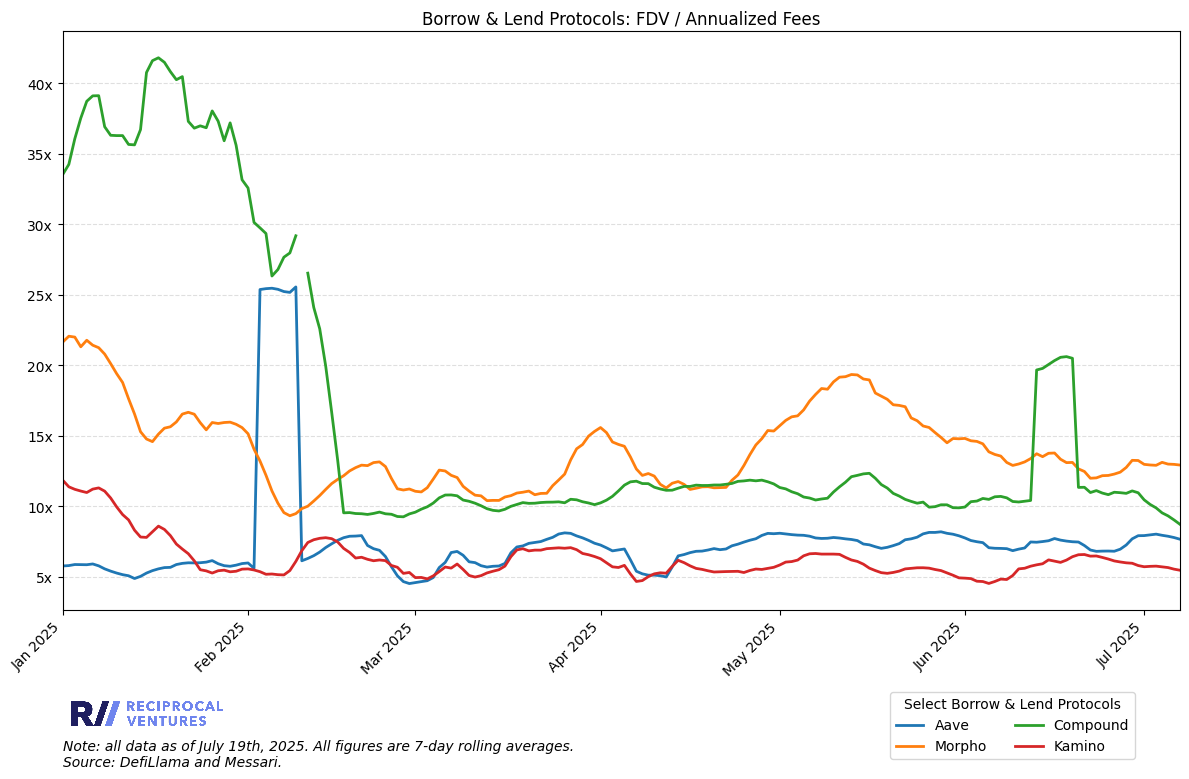


Borrow & Lend Protocols FDV / Annualized Fees Statistics (Excluding Kamino):
Median FDV / Annualized Fees: 9x
80th Percentile FDV / Annualized Fees: 11x
20th Percentile FDV / Annualized Fees: 9x
Latest Multiple: 9x

Kamino FDV / Annualized Fees Statistics:
Median FDV / Annualized Fees: 6x
80th Percentile FDV / Annualized Fees: 7x
20th Percentile FDV / Annualized Fees: 5x
Latest Multiple: 5x



In [13]:
# Call the function for perp dexs
borrow_lend_protocols = {'aave': 'Aave',
                         'morpho': 'Morpho',
                         'compound': 'Compound',
                         'kamino': 'Kamino',
         }

# 'bottom_metric' should be 'Fees' or 'Revenue'; 'top_metric' should be 'FDV' or 'MCAP'
start_date = '2025-01-01'
assets = borrow_lend_protocols
breakout_asset = ('kamino', 'Kamino')
bottom_metric = 'Fees'
top_metric = 'FDV'
category_title = 'Borrow & Lend Protocols'

borrow_lend_stats, breakout_stats = revenue_vs_fdv_asset(
    start_date     = start_date,
    assets         = assets,
    breakout_asset = breakout_asset,
    bottom_metric  = bottom_metric,
    top_metric     = top_metric,
    category_title = category_title
)

In [14]:
# Function for plotting fees comparison
def fees_and_revenue_comparison(start_date, asset_slugs, asset_names):
    master_df = None
    
    # Load fees and revenue data
    for asset_slug in asset_slugs:
        metrics = ['Fees', 'Revenue']
        interim_df = None
        for metric in metrics:
            asset_path = f"raw-data/defillama-raw-data/daily{metric}_data/{asset_slug}_{metric}.json"
            with open(asset_path) as asset_f:
                asset_data = json.load(asset_f)

            # Clean up asset dataframe
            asset_df = pd.DataFrame(asset_data["totalDataChart"], columns=["timestamp", f"{asset_slug}-{metric}"])
            asset_df["date"] = pd.to_datetime(asset_df["timestamp"], unit="s")
            asset_df = asset_df[["date", f"{asset_slug}-{metric}"]]
        
            # Merge metric-level asset dataframes for a given asset into the interim dataframe
            interim_df = asset_df if interim_df is None else interim_df.merge(asset_df, on="date", how="inner")
            interim_df = interim_df.sort_values("date").reset_index(drop=True)

        # Merge interim dataframe into the master dataframe
        master_df = interim_df if master_df is None else master_df.merge(interim_df, on="date", how="outer")
        master_df = master_df.sort_values("date").reset_index(drop=True)

    # Calculate fees comparison and revenue comparison
    for metric in metrics:
        master_df[f'{asset_slugs[0]} as % of {asset_slugs[1]}: {metric}'] = (master_df[f'{asset_slugs[0]}-{metric}'] / master_df[f'{asset_slugs[1]}-{metric}']).rolling(window=7).mean()
    
    master_df = master_df[['date',f'{asset_slugs[0]} as % of {asset_slugs[1]}: {metrics[0]}',f'{asset_slugs[0]} as % of {asset_slugs[1]}: {metrics[1]}']]
    
    # Cut off df_master to only be after start date
    master_df = master_df[master_df['date'] >= start_date]
    
    # Create the line chart
    fig, ax = plt.subplots(figsize=(10, 6))

    # Create color palette
    color_list = ['#1f1f60',
                'grey',
               ]
            
    # Prepare the values and colors in the right order
    dates   = master_df['date']
    series_list = [master_df[f'{asset_slugs[0]} as % of {asset_slugs[1]}: {metric}'] for metric in metrics]
    labels_list  = [metric for metric in metrics]
    colors_list = [color for color in color_list]
    
    # Plotting the line chart with custom colors
    for i, metric in enumerate(metrics):
        ax.plot(
            dates, 
            series_list[i], 
            label = labels_list[i], 
            color = colors_list[i],
            linewidth=2
        )
    
    # Setting labels and title
    ax.set_title(f'{asset_names[0]} as % of {asset_names[1]}: {metrics[0]} and {metrics[1]}')
    ax.margins(x=0)
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x*100:,.0f}%'))
    ax.set_ylim(bottom=0)

    # Add grid lines for better readability
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    # Add logo
    add_logo(ax, position=(0.08, -0.25))
    
    # Add sources and note
    text_box = ax.text(0, -0.40, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: DefiLlama",
                       ha='left', transform=ax.transAxes, fontsize=10,
                       bbox=dict(facecolor='white', alpha=0), fontstyle='italic')
    
    # Center the legend below the chart
    plt.legend(title=f'Select {category_title}', bbox_to_anchor=(0.85, -0.17), loc='upper center', ncol=2)
    
    # Ensure the layout adapts to fit all elements (legend, text, etc.)
    plt.tight_layout()
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}/{asset_names[0]} as % of {asset_names[1]} {metrics[0]} and {metrics[1]}.png", dpi=300, bbox_inches='tight')
    
    # Show
    plt.show()

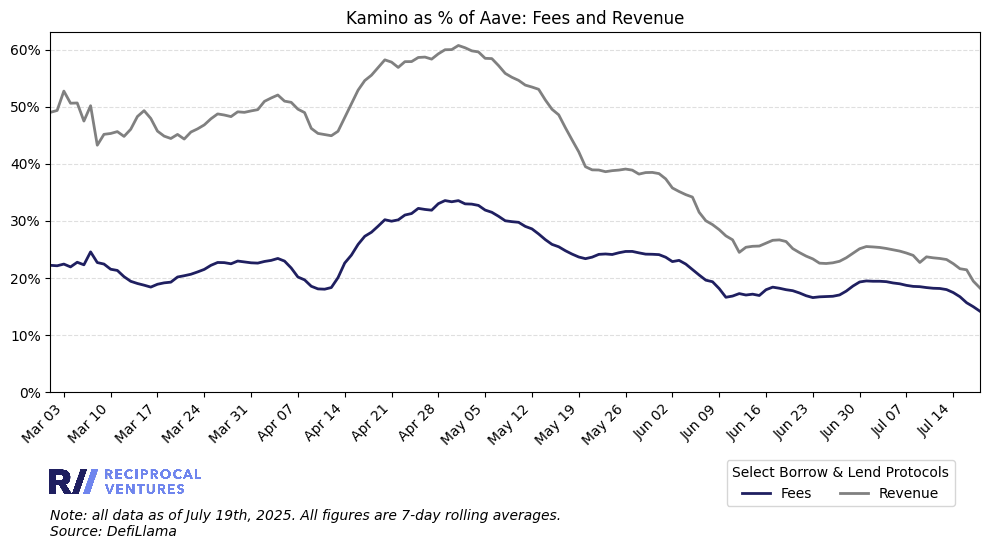

In [15]:
# call the function
start_date = '2025-03-01'
asset_slugs = ['kamino', 'aave']
asset_names = ['Kamino', 'Aave']

fees_and_revenue_comparison(start_date, asset_slugs, asset_names)

In [16]:
# Function for plotting gross margin for a given asset
def category_gross_margin_comparison(start_date, categories):
    master_df = None
    
    # Load fees and revenue data
    for category, assets in categories.items():
        # Load each asset’s raw Fees+Revenue into a category_df
        category_df = None
        for slug in assets:
            # load both metrics for this asset
            dfs = []
            for metric in ['Fees', 'Revenue']:
                path = f"raw-data/defillama-raw-data/daily{metric}_data/{slug}_{metric}.json"
                obj  = json.load(open(path))
                df   = pd.DataFrame(obj["totalDataChart"], columns=["timestamp", f"{slug}-{metric}"])
                df["date"] = pd.to_datetime(df["timestamp"], unit="s")
                df = df[["date", f"{slug}-{metric}"]]
                dfs.append(df)

            # Join this asset’s Fees & Revenue
            asset_df = dfs[0].merge(dfs[1], on="date", how="outer").sort_values("date")
            num_cols = asset_df.columns.difference(['date'])
            asset_df[num_cols] = asset_df[num_cols].apply(pd.to_numeric, errors='coerce')
            asset_df[num_cols] = asset_df[num_cols].fillna(0)

            # Merge into the rolling category_df
            if category_df is None:
                category_df = asset_df
            else:
                category_df = category_df.merge(asset_df, on="date", how="outer")
                num_cols = category_df.columns.difference(['date'])
                category_df[num_cols] = category_df[num_cols].apply(pd.to_numeric, errors='coerce')
                category_df[num_cols] = category_df[num_cols].fillna(0)

        # Sum across all the asset columns to get category totals
        fee_cols = [c for c in category_df if c.endswith('-Fees')]
        rev_cols = [c for c in category_df if c.endswith('-Revenue')]

        # Coerce each to numeric and fill
        for col in fee_cols + rev_cols:
            category_df[col] = (
                pd.to_numeric(category_df[col], errors='coerce')
                  .fillna(0).infer_objects(copy=False)
            )
        
        category_df[f'{category}-Fees']    = category_df[fee_cols].sum(axis=1)
        category_df[f'{category}-Revenue'] = category_df[rev_cols].sum(axis=1)

        # Compute gross margin and 7-day rolling
        category_df[f'{category}-gross-margin']    = (
            category_df[f'{category}-Revenue'] / category_df[f'{category}-Fees']
        )
        category_df[f'{category}-gross-margin-7d'] = (
            category_df[f'{category}-gross-margin'].rolling(window=7).mean()
        )

        # Trim down to just the one series we care about
        out = category_df[['date', f'{category}-gross-margin-7d']]

        # Merge *that* into the master_df exactly once per category
        if master_df is None:
            master_df = out
        else:
            master_df = master_df.merge(out, on="date", how="outer")

    # Cut off df_master to only be after start date
    master_df = master_df[master_df['date'] >= start_date]
    
    # Create the line chart
    fig, ax = plt.subplots(figsize=(10, 8))

    # Create color palette
    color_list = ['#1f1f60',
                '#313EA5',
                '#494949',
                'grey',
                '#333333',
                '#5F5F5F',
                '#8A8A8A',
                '#B6B6B6'
               ]

    color_palette = {}
            
    # Prepare the values and colors in the right order
    dates   = master_df['date']
    series_list = [master_df[f'{category}-gross-margin-7d'] for category in categories]
    labels_list  = [category for category, _ in categories.items()]
    colors_list = [color for color in color_list]
    
    # Plotting the line chart with custom colors
    for i, (category, _) in enumerate(categories.items()):
        ax.plot(
            dates, 
            series_list[i], 
            label = labels_list[i], 
            color = colors_list[i],
            linewidth=2
        )
    
    # Setting labels and title
    ax.set_title(f'Gross Margin by Category')
    ax.margins(x=0)
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x*100:,.0f}%'))
    ax.set_ylim(bottom=0)

    # Add grid lines for better readability
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    # Add logo
    add_logo(ax, position=(0.08, -0.15))
    
    # Add sources and note
    text_box = ax.text(0, -0.33, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nGross margin calculated as fees / revenue, which is the % of fees the protocol keeps.\nFees data does not account for offchain rebates or incentives.\nCategory averages not weighted by FDV.\nSource: DefiLlama",
                       ha='left', transform=ax.transAxes, fontsize=10,
                       bbox=dict(facecolor='white', alpha=0), fontstyle='italic')
    
    # Center the legend below the chart
    plt.legend(title=f'Select Categories', bbox_to_anchor=(0.85, -0.13), loc='upper center', ncol=1)
    
    # Ensure the layout adapts to fit all elements (legend, text, etc.)
    plt.tight_layout()
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}/category-gross-margins.png", dpi=300, bbox_inches='tight')
    
    # Show
    plt.show()

    print(master_df.tail(5))

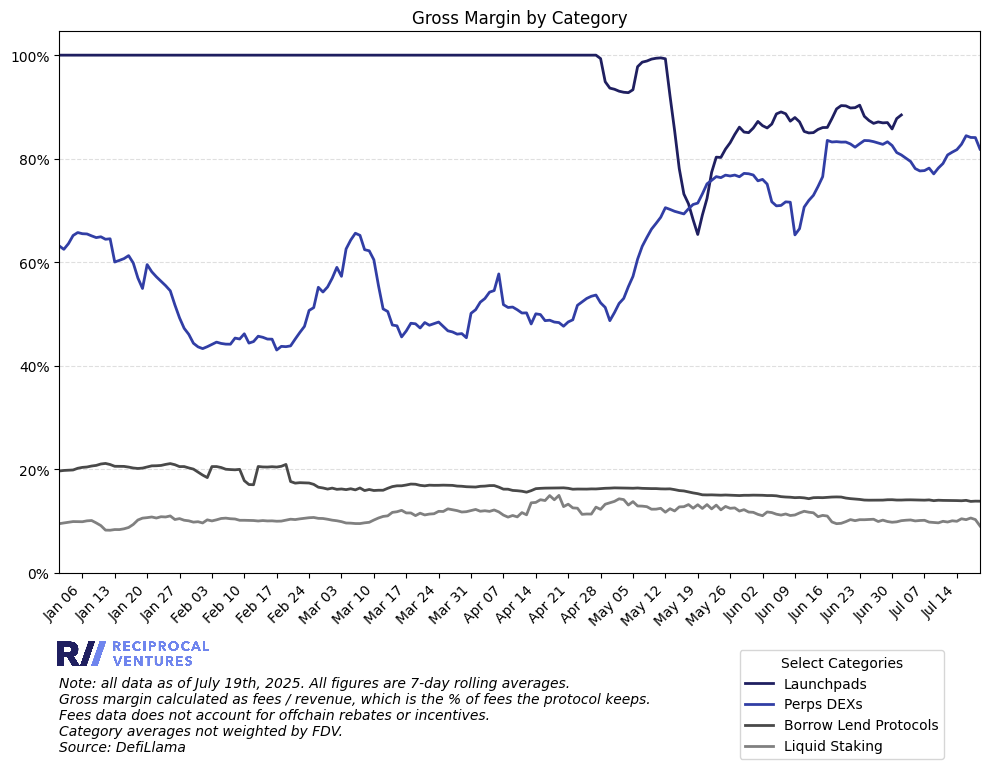

           date  Launchpads-gross-margin-7d  Perps DEXs-gross-margin-7d  \
2260 2025-07-15                         NaN                    0.827874   
2261 2025-07-16                         NaN                    0.844380   
2262 2025-07-17                         NaN                    0.841012   
2263 2025-07-18                         NaN                    0.840781   
2264 2025-07-19                         NaN                    0.818462   

      Borrow Lend Protocols-gross-margin-7d  Liquid Staking-gross-margin-7d  
2260                               0.139149                        0.104362  
2261                               0.139936                        0.102629  
2262                               0.137894                        0.105810  
2263                               0.138419                        0.102820  
2264                               0.138290                        0.090454  


In [17]:
# call the function
categories = {
    'Launchpads':{'pumpfun': 'Pump.Fun',
              'uniderp': 'Nniderp',
              'launch-coin-on-believe': 'Launch Coin on Believe',
              'launchlab': 'launchlab'
             },
    'Perps DEXs':{
        'hyperliquid': 'Hyperliquid',
                'drift': 'Drift',
              'gmx': 'GMX',
              'jupiter': 'Jupiter'
         },
    'Borrow Lend Protocols':
    {'aave': 'Aave',
     'compound': 'Compound',
     'kamino': 'Kamino',
         },
    'Liquid Staking' : {'lido': 'Lido',
                        'jito-liquid-staking': 'Jito Liquid Staking',
                        'rocket-pool': 'Rocket Pool',
                        'sanctum-validator-lsts': 'Sanctum Validator LSTs'
                       }
}
 
start_date = '2025-01-01'

category_gross_margin_comparison(start_date, categories)

In [18]:
# Funciton for plotting OI as % FDV for a given asset and comparing to BTC

def price_vs_oi(asset_id, asset_name, start_date):
    # Load price data
    with open(f'raw-data/messari-raw-data/messari_{asset_id}_price.json', 'r') as f:
        price_data = json.load(f)
    
    points = price_data['data']['points']
    price_df = pd.DataFrame(points, columns=[
        'timestamp',
        'open',
        'high',
        'low',
        'close',
        'volume'
    ])
    price_df["date"] = pd.to_datetime(price_df["timestamp"], unit="s")
    price_df = price_df[['date','close']]
    
    # Calculate trailing 7-day average
    price_df['close-7d'] = price_df['close'].rolling(window=7).mean()

    # Load fundring rate data for the asset slug
    with open (f'raw-data/messari-raw-data/messari_{asset_id}_futures-open-interest.json', 'r') as f:
        rate_data = json.load(f)

    points = rate_data['data']['points']
    oi_df = pd.DataFrame(points, columns=[
        'timestamp',
        "open-interest"
    ])
    oi_df['date'] = pd.to_datetime(oi_df['timestamp'], unit='s')
    oi_df = oi_df[['date', 'open-interest']]
    oi_df = oi_df.rename(columns={"open-interest": "oi"})
     # Calculate trailing 7-day average
    oi_df['oi-7d'] = oi_df['oi'].rolling(window=7).mean()

    # Merge datasets for asset slug
    df = pd.merge(price_df, oi_df, on="date", how="inner")

    # Cut off df to only be after start date
    df = df[df['date'] >= start_date]

    # 6) Plot
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    # Area: Price
    ax1.fill_between(
        df["date"], df["close-7d"],
        color="#a4a2a8", alpha=1,
        label=f"{asset_name} Price"
    )
    ax1.yaxis.set_major_formatter(
            mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    
    ax1.set_ylabel("Price")
    ax1.margins(x=0)                  # no extra padding
    ax1.set_ylim(bottom=0)

    # Monthly ticks, lighter crowding
    ax1.xaxis.set_major_locator(MonthLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
  
    plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")
    
    # Line: OI
    ax2 = ax1.twinx()
    ax2.plot(
        df["date"], df["oi-7d"],
        color="#1f1f60", linewidth=2,
        label=f"{asset_name} Open Interest"
    )
    ax2.set_ylabel("Open Interest")
    ax2.yaxis.set_major_formatter(
            mtick.FuncFormatter(lambda x, _: f'${x/1e6:,.0f}m'))
    ax2.set_ylim(bottom=0)
    ax2.margins(x=0)                  # no extra padding

    
    # Title, grid & legend
    ax1.set_title(f"{asset_name}: Price vs Open Interest", fontsize=14)
    ax1.grid(axis="y", linestyle="--", alpha=0.5)
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc="upper left")
    
    # Save & show
    add_logo(ax1, position=(0.075, -0.21))
    plt.figtext(0.075, -0.02, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: Messari", ha='left', fontsize=10, style='italic')
    plt.tight_layout()
    plt.savefig(f"{plots_filepath}/{asset_id}_price_vs_oi_7d.png", dpi=300, bbox_inches="tight")
    plt.show()
    
    # Debug print
    print(df.tail(5))

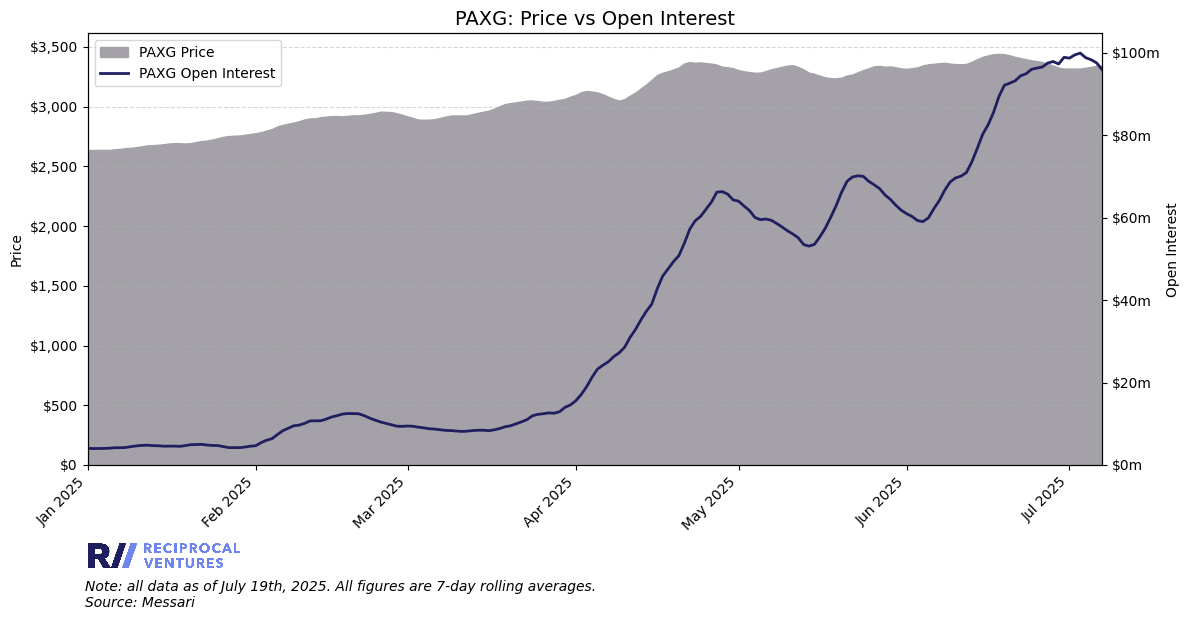

           date        close     close-7d            oi         oi-7d
1218 2025-07-03  3336.555435  3317.960538  9.558010e+07  9.995608e+07
1219 2025-07-04  3344.412602  3324.602522  9.473708e+07  9.883804e+07
1220 2025-07-05  3344.256792  3332.169462  9.745582e+07  9.835092e+07
1221 2025-07-06  3335.385678  3340.350078  9.668243e+07  9.759117e+07
1222 2025-07-07  3344.454455  3343.764077  9.461452e+07  9.597908e+07


In [19]:
assets = {'pax-gold': 'PAXG'}
start_date = '2025-01-01'

for asset_id, asset_name in assets.items():
    price_vs_oi(asset_id, asset_name, start_date)

In [20]:
# Funciton for plotting OI vs circulating supply for a given asset


def oi_vs_circulating_mcap_vs_funding_rate(asset_id, asset_name, date):
    # Load price data
    with open(f'raw-data/messari-raw-data/messari_{asset_id}_price.json', 'r') as f:
        price_data = json.load(f)

    points = price_data['data']['points']
    price_df = pd.DataFrame(points, columns=[
    'timestamp',
    'open',
    'high',
    'low',
    'close',
    'volume'
    ])
    price_df["date"] = pd.to_datetime(price_df["timestamp"], unit="s")
    price_df = price_df[['date','close']]

    # Calculate traling 7-dday average
    price_df['close-7d'] = price_df['close'].rolling(window=7).mean()

    # Load supply data
    with open(f'raw-data/messari-raw-data/messari_{asset_id}_supply.json', 'r') as f:
        supply_data = json.load(f)

    points = supply_data['data']['points']
    supply_df = pd.DataFrame(points, columns=[
    'timestamp',
    'circulating-supply',
    'total-supply'
    ])
    supply_df["date"] = pd.to_datetime(supply_df["timestamp"], unit="s")
    supply_df = supply_df[['date','circulating-supply']]

    # Calculate traling 7-dday average
    supply_df['circulating-supply-7d'] = supply_df['circulating-supply'].rolling(window=7).mean()
    
    # Load oi data
    with open(f"raw-data/messari-raw-data/messari_{asset_id}_futures-open-interest.json", "r") as f:
        oi_data = json.load(f)
    
    points = oi_data['data']['points']
    oi_df = pd.DataFrame(points, columns=[
        'timestamp',
        'open-interest'
    ])
    oi_df["date"] = pd.to_datetime(oi_df["timestamp"], unit="s")
    oi_df = oi_df[['date','open-interest']]
    oi_df['open-interest-7d'] = oi_df['open-interest'].rolling(window=7).mean()
    
    # Load mcap data
    with open(f"raw-data/messari-raw-data/messari_{asset_id}_marketcap.json", 'r') as f:
        mcap_data = json.load(f)
    
    points = mcap_data['data']['points']
    mcap_df = pd.DataFrame(points, columns=[
        'timestamp',
        'circulating-marketcap',
        'circulating-marketcap-dominance',
        'fully-diluted-marketcap'
    ])
    mcap_df["date"] = pd.to_datetime(mcap_df["timestamp"], unit="s")
    mcap_df = mcap_df[['date','circulating-marketcap']]
    mcap_df['circulating-marketcap-7d'] = mcap_df['circulating-marketcap'].rolling(window=7).mean()

    # Load fundring rate data
    with open (f'raw-data/messari-raw-data/messari_{asset_id}_futures-funding-rate.json', 'r') as f:
        rate_data = json.load(f)

    points = rate_data['data']['points']
    rate_df = pd.DataFrame(points, columns=[
        'timestamp',
        "funding-rate-open-interest",
        "funding-rate-volume"
    ])
    rate_df['date'] = pd.to_datetime(rate_df['timestamp'], unit='s')
    rate_df = rate_df[['date', 'funding-rate-open-interest']]
    rate_df['funding-rate-open-interest-7d'] = rate_df['funding-rate-open-interest'].rolling(window=7).mean()
    
    # Merge datasets
    step1_df = pd.merge(price_df, supply_df, on="date", how="inner")
    step2_df = pd.merge(step1_df, oi_df, on='date', how='inner')
    step3_df = pd.merge(step2_df, mcap_df, on='date', how='inner')
    df = pd.merge(step3_df, rate_df, on='date', how='inner')
    df['oi_as_%_circ_mcap'] = df['open-interest'] / df['circulating-marketcap'] * 100 # Multiply by 100 to convert to % terms
    df['oi_as_%_circ_mcap_7d'] = df['oi_as_%_circ_mcap'].rolling(window=7).mean()
    
    # Drop any rows without a full 7‑day average, plus the very last day
    plot_df = df[df["open-interest-7d"].notna()].iloc[:-1]
    
    # two rows: top for MCap + OI, bottom for funding rates
    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1,
        figsize=(12, 8),
        sharex=True,
        gridspec_kw={'height_ratios': [3, 1],
                    'hspace':0.05}
    )

    # TOP PANEL: Circulating Market Cap (area) + Open Interest (line)

    # area: 7-day MCap
    ax_top.fill_between(
        plot_df["date"],
        plot_df["close"],
        color="#a4a2a8", alpha=1,
        label="Close Price"
    )
    ax_top.set_ylabel("Close Price")
    ax_top.yaxis.set_major_formatter(
        mtick.FuncFormatter(lambda x, _: f'${x:,.2f}')
    )
    ax_top.set_ylim(0)

    # line: 7-day OI on a second y-axis
    ax_oi = ax_top.twinx()
    ax_oi.plot(
        plot_df["date"],
        plot_df["circulating-supply"],
        color="#1f1f60", linewidth=2,
        label="Circulating Supply"
    )
    ax_oi.set_ylabel("Circulating Supply")
    ax_oi.yaxis.set_major_formatter(
        mtick.FuncFormatter(lambda x, _: f'{x/1e6:,.0f}m')
    )
    ax_oi.set_ylim(0)

    # date formatting
    ax_top.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
    ax_top.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    plt.setp(ax_top.get_xticklabels(), rotation=45, ha="right")


    # BOTTOM PANEL: Funding Rate (OI-weighted)

    ax_bot.plot(
        plot_df['date'],
        plot_df['funding-rate-open-interest'],
        color="black", linewidth=1.2,
        label="Funding Rate"
    )
    ax_bot.set_ylabel("Funding Rate")
    ax_bot.yaxis.set_major_formatter(
        mtick.FuncFormatter(lambda x, _: f'{x*10000:,.0f}bps')
    )
    
    # line: add OI as % of Circ. Mcap to bottom chart
    ax_perc = ax_bot.twinx()
    ax_perc.plot(
        plot_df["date"],
        plot_df["oi_as_%_circ_mcap"],
        color="red", linewidth=1.2,
        label="OI as % of Circ. Mcap"
    )
    ax_perc.set_ylabel("OI (% Circ. Mcap)")
    ax_perc.yaxis.set_major_formatter(
        mtick.FuncFormatter(lambda x, _: f'{x:,.0f}%')
    )
    ax_perc.set_ylim(0)

    # 1) remove horizontal margins
    ax_top.margins(x=0)
    ax_bot.margins(x=0)

    # 3) bottom axis: month & two-digit year
    from matplotlib.dates import MonthLocator, DateFormatter

    ax_bot.xaxis.set_major_locator(MonthLocator())
    ax_bot.xaxis.set_major_formatter(DateFormatter("%b %y"))
    plt.setp(ax_bot.get_xticklabels(), rotation=45, ha="right")

     # ─── TITLES ───
    ax_top.set_title(f"{asset_name}: Price, Circulating Supply, and Open Interest", fontsize=14)

    # Pull legend handles from both axes
    h1, l1 = ax_top.get_legend_handles_labels()
    h2, l2 = ax_oi.get_legend_handles_labels()
    h3, l3 = ax_bot.get_legend_handles_labels()
    h4, l4 = ax_perc.get_legend_handles_labels()
    handles = h1 + h2 + h3 + h4
    labels  = l1 + l2 + l3 + l4

    # ─── make room at the bottom ───
    fig.subplots_adjust(bottom=0.2)

    # ─── FIGURE‐LEVEL LEGEND ───
    legend = fig.legend(
        handles, labels,
        loc="lower center",
        ncol=2,
        frameon=True,
        bbox_to_anchor=(0.5, 0.06),
        fontsize=10
    )
    # give it a thin black border
    frame = legend.get_frame()
    frame.set_edgecolor("black")
    frame.set_linewidth(0.5)
    frame.set_alpha(1)

    # ─── SMALLER LOGO, ALIGNED TO THE LEFT ───
    # position is in axis‐coordinates of ax_bot: x=0.075, y slightly below the axis
    add_logo(ax_bot, position=(0.075, -0.6), zoom=0.1)

    # ─── FOOTNOTE, SAME LEFT MARGIN ───
    fig.text(
        0.12, 0.03,
        f"Note: all data as of {date}.\nFunding rate is OI-weighted.\nSource: Messari",
        ha="left",
        fontsize=8,
        style="italic"
    )

    plt.savefig(
        f"{plots_filepath}/{asset_name}_price_vs_circ-supply_vs_funding-rate_vs_oi.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    print(plot_df.tail(5))

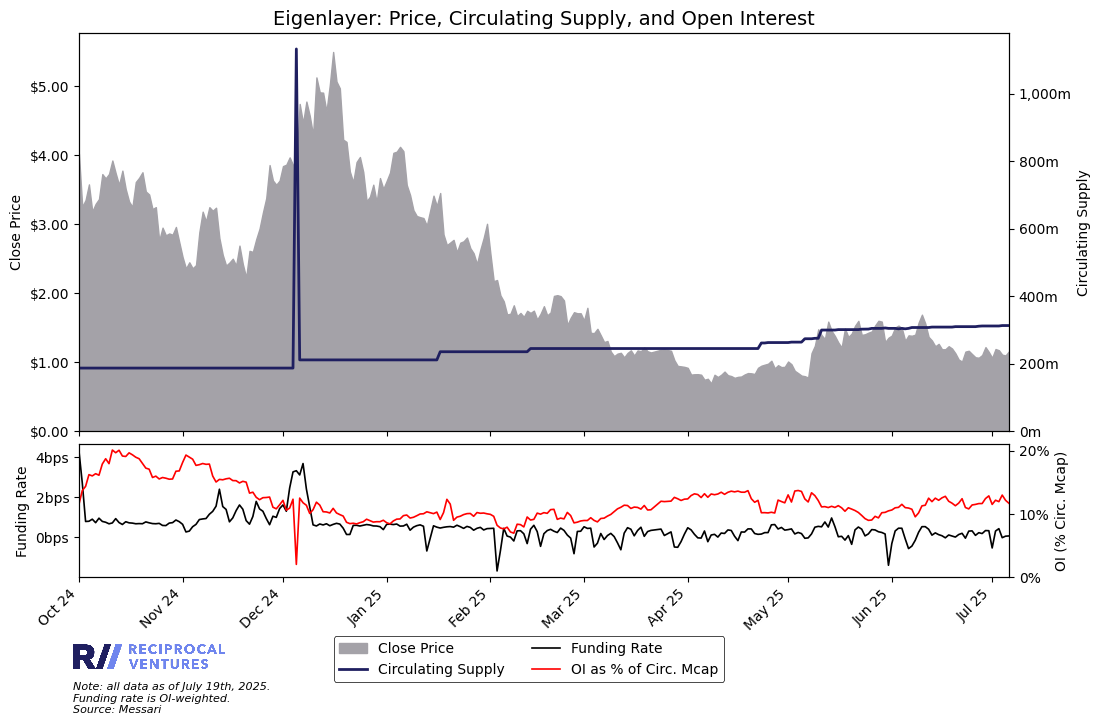

          date     close  close-7d  circulating-supply  circulating-supply-7d  \
270 2025-07-02  1.189016  1.120803        3.112793e+08           3.109060e+08   
271 2025-07-03  1.171453  1.135414        3.112793e+08           3.111846e+08   
272 2025-07-04  1.106842  1.141685        3.125667e+08           3.114632e+08   
273 2025-07-05  1.095947  1.140879        3.125667e+08           3.116471e+08   
274 2025-07-06  1.154190  1.131978        3.125667e+08           3.118310e+08   

     open-interest  open-interest-7d  circulating-marketcap  \
270   4.497808e+07      4.170018e+07              370115943   
271   4.347959e+07      4.248365e+07              364648921   
272   4.484528e+07      4.340976e+07              345961903   
273   4.157670e+07      4.365483e+07              342556599   
274   4.210004e+07      4.295640e+07              360761234   

     circulating-marketcap-7d  funding-rate-open-interest  \
270              3.484842e+08                3.207910e-05   
271         

In [21]:
assets = {'eigenlayer': 'Eigenlayer'}

for asset_id, asset_name in assets.items():
    oi_vs_circulating_mcap_vs_funding_rate(asset_id, asset_name, date)

In [22]:
# Function to stablecoin mcap
def stablecoin_mcap_by_chain(asset, start_date, end_date, n):
    chain_colors = ['#1f1f60',
                    '#191F98',
                    '#313EA5',
                    '#4A5DB2',
                    '#637BBF',
                    '#7C9ACC',
                    '#94B9D9',
                    '#ADD8E6',
                    '#333333',
                    '#494949',
                    '#5F5F5F',
                    '#757575',
                    '#8A8A8A',
                    '#A0A0A0',
                    '#B6B6B6',
                    '#CCCCCC'
                   ]
    
    df_master = None
    
    counter = 0
    
    start_date_dt = pd.to_datetime(start_date)
    end_date_dt = pd.to_datetime(end_date) - pd.Timedelta(days=1)

    with open(f"raw-data/defillama-raw-data/stablecoins/{asset}.json", 'r') as f:
        data = json.load(f)
    
    # Flatten records
    records = []
    for chain, chain_data in data.get('chainBalances', {}).items():
        for entry in chain_data.get('tokens', []):
            df_date = pd.to_datetime(entry.get('date'), unit='s')
            # Use circulating peggedUSD; if missing, fallback to bridgedTo peggedUSD
            value = entry.get('circulating', {}).get('peggedUSD')
            if value is None:
                value = entry.get('bridgedTo', {}).get('peggedUSD', 0)
            records.append({'date': df_date, 'chain': chain, 'peggedUSD': value})
    
    # Create DataFrame and pivot
    df_all = pd.DataFrame(records)
    df_pivot = df_all.pivot_table(index='date', columns='chain', values='peggedUSD', aggfunc='sum')
    df_pivot = df_pivot.ffill().sort_index()
    
    # Determine top_n chains *by the last date* in the index
    last_date   = df_pivot.index.max()
    last_values = df_pivot.loc[last_date]
    sorted_chains = last_values.sort_values(ascending=False)
    top_chains  = list(sorted_chains.index[:n])
    other_chains = list(sorted_chains.index[n:])
    
    # Build final DataFrame with 'Other' aggregation
    df_top = df_pivot[top_chains].copy()
    df_top['Other'] = df_pivot[other_chains].sum(axis=1)
    df_master = df_top.reset_index()

    # Filter by appropriate dates
    df_master = df_master.loc[(df_master['date'] >= start_date_dt) &
    (df_master['date'] < end_date_dt)
    ]
        
    # Sort your master dataframe by date
    df_master = df_master.sort_values('date')

    # Grab chain names
    chains = df_master.columns[1:].tolist()

    # Calculate 7-day trailing averages for each chain column
    df_master[chains] = df_master[chains].rolling(window=7, min_periods=1).mean()
    
    # Prepare the values and colors in the right order
    dates   = df_master['date']
    series  = [df_master[chain] for chain in chains]
    colors = chain_colors[:len(chains)]
    
    # Plot a single stacked‐area call
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.stackplot(
        dates,
        *series,
        labels=chains,
        colors=colors
    )
    
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000000000:.0f}b'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.xticks(rotation=45)
    
    ax.legend(loc='upper left', bbox_to_anchor=(0,1), ncol=2)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    add_logo(ax, position=(0.08, -0.18))
    ax.margins(x=0)
    plt.figtext(0.12, -0.11, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: DefiLlama", ha='left', fontsize=10, style='italic')
    ax.set_title(f'{asset} Market Cap by Chain')
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}/{asset}-mcap-by-chain.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    print(df_master.tail(5))

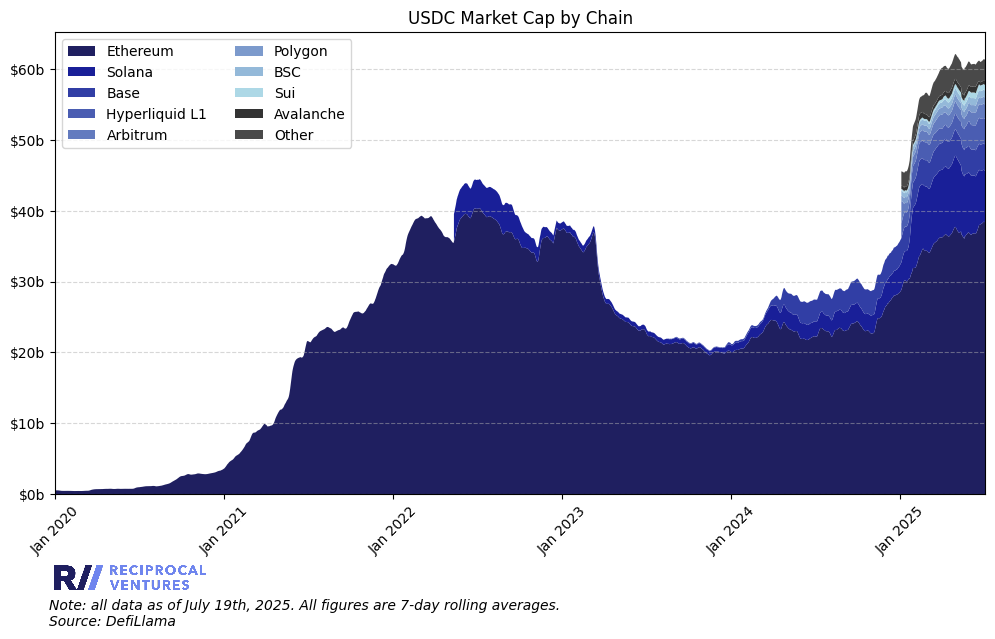

chain       date      Ethereum        Solana          Base  Hyperliquid L1  \
2483  2025-06-29  3.839915e+10  7.372445e+09  3.725148e+09    3.581493e+09   
2484  2025-06-30  3.845831e+10  7.335538e+09  3.727403e+09    3.570396e+09   
2485  2025-07-01  3.843225e+10  7.312194e+09  3.727460e+09    3.571018e+09   
2486  2025-07-02  3.841578e+10  7.270296e+09  3.728744e+09    3.569989e+09   
2487  2025-07-03  3.837760e+10  7.274354e+09  3.735957e+09    3.565608e+09   

chain      Arbitrum       Polygon           BSC           Sui     Avalanche  \
2483   2.035283e+09  9.748179e+08  9.899559e+08  7.900930e+08  5.516055e+08   
2484   2.051748e+09  9.781872e+08  9.899484e+08  7.895229e+08  5.749489e+08   
2485   2.056696e+09  9.823684e+08  9.899494e+08  7.869302e+08  6.019141e+08   
2486   2.059059e+09  9.855120e+08  9.899725e+08  7.843222e+08  6.236897e+08   
2487   2.068251e+09  9.875778e+08  9.899854e+08  7.894173e+08  6.393231e+08   

chain         Other  
2483   2.928763e+09  
2484   2.941

In [23]:
asset = 'USDC'
start_date = '2020-01-01'
end_date = today
n = 9 # number of protocols to show, max is number pulled down in the raw data

stablecoin_mcap_by_chain(asset, start_date, end_date, n)

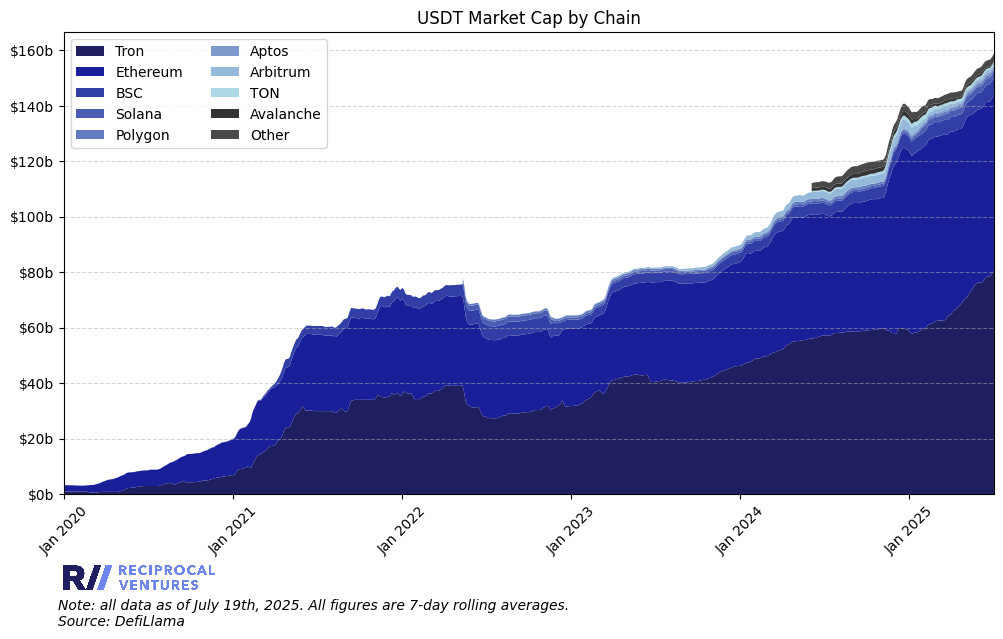

chain       date          Tron      Ethereum           BSC        Solana  \
2769  2025-06-29  7.964543e+10  6.310311e+10  6.282378e+09  2.317759e+09   
2770  2025-06-30  7.986875e+10  6.314239e+10  6.282371e+09  2.317760e+09   
2771  2025-07-01  8.009778e+10  6.333302e+10  6.282368e+09  2.317754e+09   
2772  2025-07-02  8.013239e+10  6.346498e+10  6.282363e+09  2.317752e+09   
2773  2025-07-03  8.015799e+10  6.358902e+10  6.282359e+09  2.317760e+09   

chain       Polygon         Aptos      Arbitrum           TON     Avalanche  \
2769   1.024477e+09  8.188262e+08  8.749037e+08  5.752168e+08  5.086654e+08   
2770   1.028486e+09  8.169101e+08  8.509188e+08  5.709310e+08  5.115191e+08   
2771   1.032107e+09  8.154874e+08  8.260172e+08  5.666453e+08  5.114884e+08   
2772   1.036010e+09  8.233195e+08  8.181843e+08  5.637882e+08  5.228864e+08   
2773   1.039882e+09  8.340061e+08  8.197687e+08  5.723596e+08  5.314269e+08   

chain         Other  
2769   2.477028e+09  
2770   2.490656e+09  
27

In [24]:
asset = 'USDT'

stablecoin_mcap_by_chain(asset, start_date, end_date, n)

In [25]:
# Function plot fees or revenue for any projects as a timeseries
def fees_or_revenue_timeseries(metric, assets, start_date, end_date):
    
    asset_colors = ['#1f1f60',
                    '#4A5DB2',
                    '#494949',
                    '#A0A0A0'
                   ]
    
    metric_identifier = 'Revenue'
    if metric == 'dailyFees':
        metric_identifier = 'Fees'
    
    df_master = None

    start_date_dt = pd.to_datetime(start_date)
    end_date_dt = pd.to_datetime(end_date) - pd.Timedelta(days=1)
    
    for asset_slug, asset_name in assets.items():
        with open(f'raw-data/defillama-raw-data/{metric}_data/{asset_slug}_{metric_identifier}.json') as f:
            data = json.load(f)
        
        # Select only the two real keys, then rename
        raw_df = pd.DataFrame(
            data['totalDataChart'],
            columns=['date', asset_name]
        )
        raw_df.rename(columns={
            'date': 'timestamp',
            f'{metric}': asset_name
        }, inplace=True)
        raw_df['date'] = pd.to_datetime(raw_df['timestamp'], unit='s')
        raw_df = raw_df[['date', asset_name]]
        raw_df[asset_name] = raw_df[asset_name].rolling(window=7).mean()
    
        # Merge dataframes
        df_master = raw_df if df_master is None else df_master.merge(raw_df, on='date', how='outer')
        df_master.fillna(0).infer_objects(copy=False)

    # Filter by appropriate dates
    df_master = df_master.loc[(df_master['date'] >= start_date_dt) &
    (df_master['date'] < end_date_dt)
    ]
    
    # Sort your master dataframe by date
    df_master = df_master.sort_values('date')
    
    # Grab the last row of numbers
    last_row = df_master.iloc[-1]

    # Grab asset names
    assets = df_master.columns[1:].tolist()

    # Prepare the values and colors in the right order
    dates   = df_master['date']
    series  = [df_master[asset] for asset in assets]
    colors = asset_colors[:len(assets)]
    
    # Plot a single stacked‐area call
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.stackplot(
        dates,
        *series,
        labels=assets,
        colors=colors
    )
    
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.xticks(rotation=45)
    
    ax.legend(loc='upper left', bbox_to_anchor=(0,1), ncol=2)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    add_logo(ax, position=(0.08, -0.17))
    ax.margins(x=0)
    plt.figtext(0.12, -0.11, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: DefiLlama", ha='left', fontsize=10, style='italic')
    if metric == 'dailyFees':
        ax.set_title(f'Daily Fees by Protocol')
    if metric == 'dailyRevenue':
        ax.set_title(f'Daily Revenue by Protocol')
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}/breakout-{metric}-timeseries.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    print(df_master.tail(5))

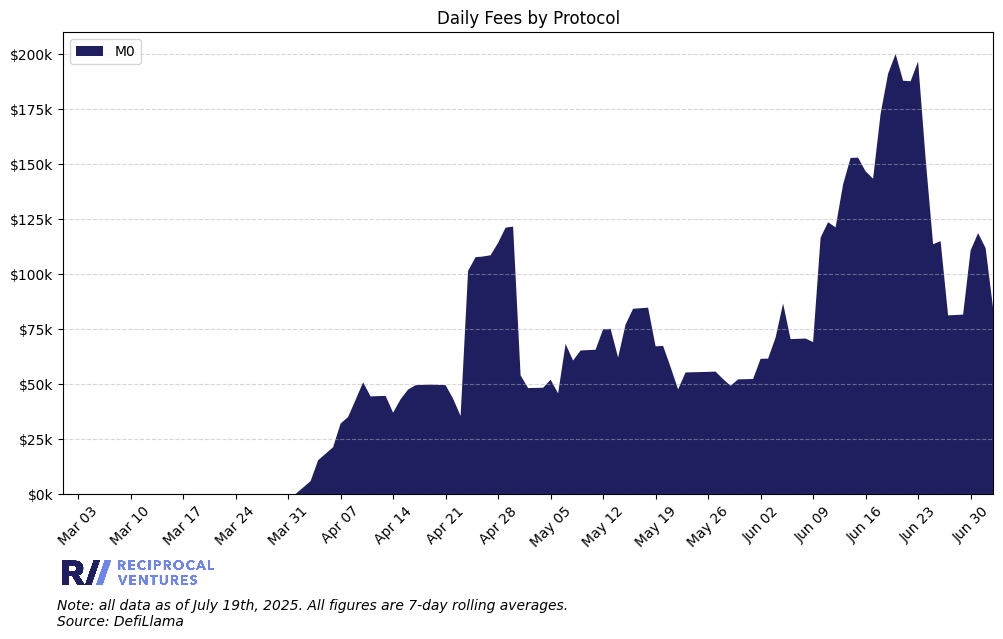

          date             M0
155 2025-06-29   81533.000000
156 2025-06-30  110659.285714
157 2025-07-01  118579.857143
158 2025-07-02  111784.285714
159 2025-07-03   84370.571429


In [26]:
# Call the function
metric = 'dailyFees' # 'dailyFees' or 'dailyRevenue'
start_date = '2025-03-01'
end_date = today
assets = {'M0': 'M0'}

fees_or_revenue_timeseries(metric, assets, start_date, end_date)

In [28]:
# Function for plotting cumulative fees or revenue
def cumulitative_metric(metric, assets):
    metric_id = 'Fees'
    if metric == 'dailyRevenue':
        metric_id = 'Revenue'

    start_date_dt = pd.to_datetime(start_date)
    end_date_dt = pd.to_datetime(end_date)
    
    for asset_slug, asset_name in assets.items():
        with open(f'raw-data/defillama-raw-data/{metric}_data/{asset_slug}_{metric_id}.json', "r") as f:
            raw_data = json.load(f)
        
        df = pd.DataFrame(raw_data["totalDataChart"], columns=["timestamp", metric_id])
        df["date"] = pd.to_datetime(df["timestamp"], unit="s")
        df = df[["date", metric_id]]
        
        # Calculate cumulative revenue
        df[f"cumulative-{metric_id}"] = df[metric_id].cumsum()

        # Find first non-zero cumulative metric date and start time series then
        nonzero_dates = df.loc[df[f"cumulative-{metric_id}"] > 0, "date"]
        if not nonzero_dates.empty:
            first_nonzero_date = nonzero_dates.iloc[0]
            df = df.loc[df["date"] >= first_nonzero_date]
        
        # Plot
        fig, ax = plt.subplots(figsize=(12, 6))
        
        # Area: Circulating market cap
        ax.fill_between(
            df["date"], df[f"cumulative-{metric_id}"],
            color="#1f1f60", alpha=1,
            label=f"Cumulative {metric_id}"
        )
        ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:,.0f}m'))
        ax.set_ylim(bottom=0)
        ax.grid(axis="y", linestyle="--", alpha=0.5)
        ax.margins(x=0) # no extra padding
        
        # Monthly ticks, lighter crowding
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=TU, interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
        
        # Title, grid & legend
        ax.set_title(f"{asset_name} Cumulative {metric_id}", fontsize=14)
        
        # Save & show
        add_logo(ax, position=(0.075, -0.2))
        plt.figtext(0.06, -0.04, f"Note: all data as of {date}.\nSource: DefiLlama", ha='left', fontsize=10, style='italic')
        plt.tight_layout()
        plt.savefig(f"{plots_filepath}/{asset_name}_cumulative_{metric_id}.png", dpi=300, bbox_inches="tight")
        plt.show()
        
        last_val = df[f"cumulative-{metric_id}"].iloc[-1]
        last_metric = f'${last_val/1e6:,.1f}m'
        print(f"Latest {asset_name} Cumulative {metric_id}: {last_metric}")

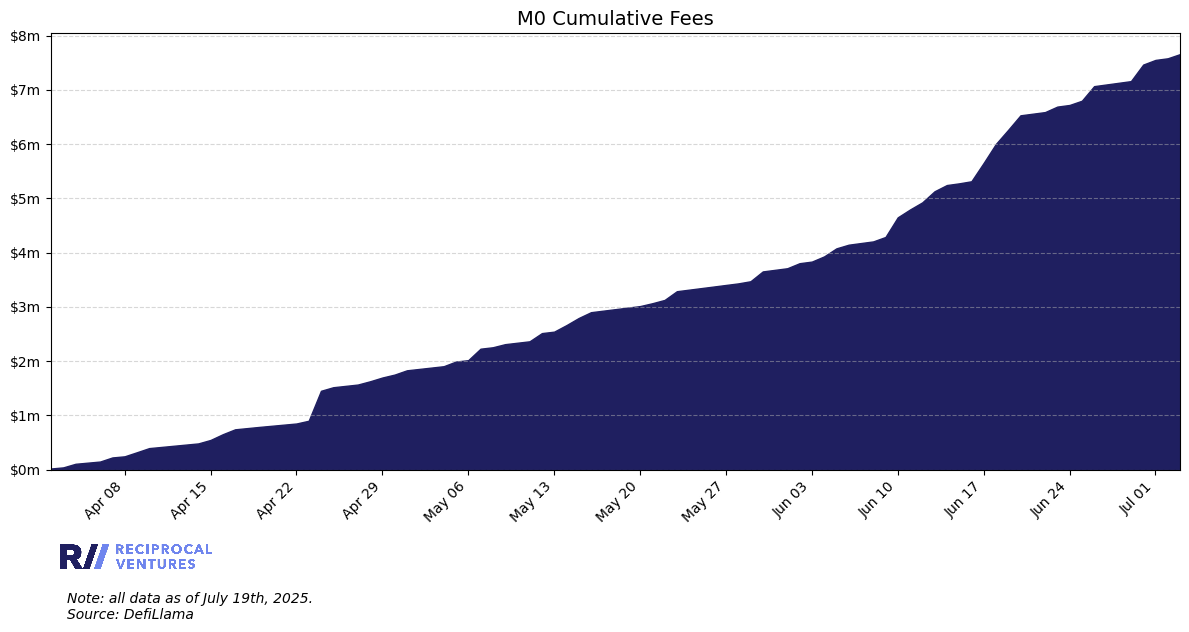

Latest M0 Cumulative Fees: $7.7m


In [29]:
metric = 'dailyFees' # 'dailyFees' or 'dailyRevenue'
assets = {'M0': 'M0'}

cumulitative_metric(metric, assets)